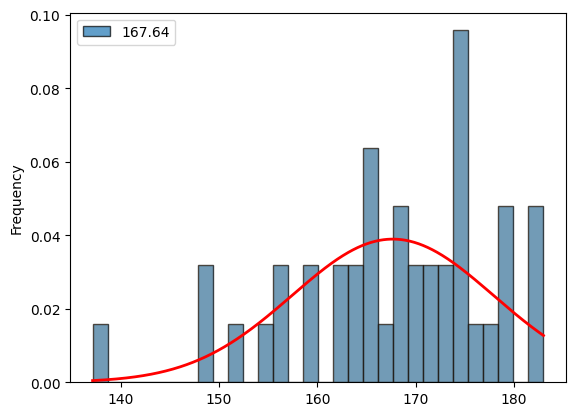

In [ ]:
import numpy as np
from scipy.stats import norm
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/content/Height.xlsx')
df.plot(
    kind='hist',
    bins=30,
    density=True,
    edgecolor='black',
    alpha=0.7
)



x = df

mu = x.mean()
sigma = x.std()

xx = np.linspace(x.min(), x.max(), 500)

plt.hist(x, bins=30, density=True, alpha=0.1)
plt.plot(xx, norm.pdf(xx, mu, sigma), 'r', linewidth=2)


plt.show()


#Histogram (own method)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.loadtxt('/content/Height.xlsx')

xmin = np.min(x)
xmax = np.max(x)

bins = 30
bin_width = (xmax - xmin) / bins
edge = np.linspace(xmin, xmax, bins+1)

def my_histogram(x, bins):
    counts = np.zeros(bins)
    for i in range(bins):
      for xi in x:
        if xi <= edge[i] and xi > edge[i + 1]:
          counts[i] += 1
        break

        if xi == xmax:
          counts[-1] += 1
        break
    return counts

counts = my_histogram(x, bins)
print(len(counts))
print(len(edge))
plt.bar(edge, counts)
plt.show()


#Manual Histogram(My  algorithem)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# load Excel properly
x = np.loadtxt('/content/Height.xlsx')

xmin = np.min(x)
xmax = np.max(x)

bins = 10
edge = np.linspace(xmin, xmax, bins+1)
bin_width = (xmax - xmin)/bins

def my_histogram(x, bins):
    counts = np.zeros(bins)

    for xi in x:

        # handle last bin explicitly
        if xi == xmax:
            counts[-1] += 1
            continue

        for i in range(bins):
            if edge[i] <= xi < edge[i+1]:
                counts[i] += 1
                break

    return counts


counts = my_histogram(x, bins)
centers = edge[:-1] + bin_width/2

plt.bar(centers, counts, width=bin_width)
plt.xlabel("Height")
plt.ylabel("Frequency")
plt.title("Histogram of Heights")
plt.show()


FileNotFoundError: /content/Height.xlsx not found.

In [ ]:
#classwork method

import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Load height data
# -------------------------
data = np.loadtxt("/content/Height.xlsx")
N = len(data)

xmin = np.min(data)
xmax = np.max(data)

nbins = 10

bin_width = (xmax - xmin) / nbins
bins = np.linspace(xmin, xmax, nbins+1)

counts = np.zeros(nbins)

# -------------------------
# Manual binning
# -------------------------
for x in data:
    index = int((x - xmin)/bin_width)
    if index == nbins:
        index = nbins-1
    counts[index] += 1

# -------------------------
# Convert to PDF
# -------------------------
pdf = counts / (N * bin_width)

# -------------------------
# Plot PDF
# -------------------------
plt.figure()

plt.bar(bins[:-1], pdf, width=bin_width, align='edge')

plt.xlabel("Height (cm)")
plt.ylabel("Probability Density")
plt.title("PDF of Height Distribution (Manual Histogram)")
plt.grid()

plt.show()
